# Fraud Detection EDA

In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the data
train = pd.read_csv(r"../data/fraudTrain.csv",index_col=0)
test = pd.read_csv(r"../data/fraudTest.csv",index_col=0)

In [3]:
#information of Training data
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

In [4]:
#information of Testing data
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 555719 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  555719 non-null  object 
 1   cc_num                 555719 non-null  int64  
 2   merchant               555719 non-null  object 
 3   category               555719 non-null  object 
 4   amt                    555719 non-null  float64
 5   first                  555719 non-null  object 
 6   last                   555719 non-null  object 
 7   gender                 555719 non-null  object 
 8   street                 555719 non-null  object 
 9   city                   555719 non-null  object 
 10  state                  555719 non-null  object 
 11  zip                    555719 non-null  int64  
 12  lat                    555719 non-null  float64
 13  long                   555719 non-null  float64
 14  city_pop               555719 non-null  i

In [5]:
#check nan values in train data
train.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [6]:
#check nan values in test data
test.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

### Feature Engineering

In [7]:
def feature_engineering(df):
    #convert to datetime column
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df["dob"] = pd.to_datetime(df["dob"])

    #create age column
    df["age"] = df["trans_date_trans_time"].dt.year - df["dob"].dt.year

    #extract time features
    df["hour"] = df["trans_date_trans_time"].dt.hour
    df["day"] = df["trans_date_trans_time"].dt.day

    #Distance calculation
    df["distance"] = np.sqrt(
                            (df["lat"]-df["merch_lat"])**2 + 
                             (df["long"]-df["merch_long"])**2
                             )
    
    return df


train = feature_engineering(train)
test = feature_engineering(test)

### Feature Selection

In [8]:
#Select useful columns

def feature_extraction(df):
    #select required columns
    # selected_cols = ['hour', 'day','category', 'amt',
    #         'gender', 'state',
    #     'distance','city_pop', 'age', 'is_fraud']
    
    unwanted_cols = ['trans_date_trans_time', 'cc_num', 'merchant',
        'first', 'last', 'street', 'city', 'zip',
       'lat', 'long', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long']
    df = df.drop(unwanted_cols,axis=1)

    return df


train = feature_extraction(train)
test = feature_extraction(test)

In [9]:
def data_label(a):
    for i in a.containers:
        a.bar_label(i)

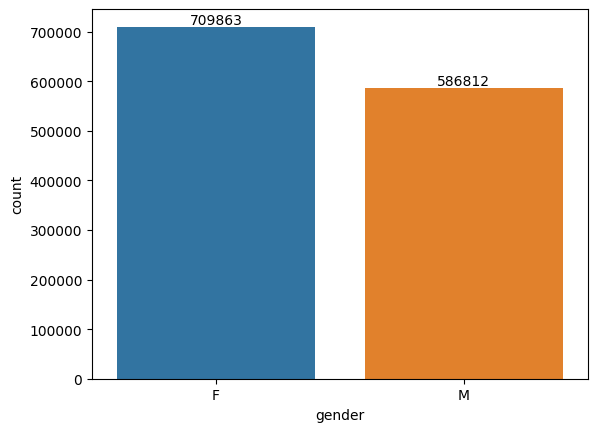

In [10]:
a = sns.countplot(x="gender",data=train,hue="gender")
data_label(a)

most of the transactions has done by females.

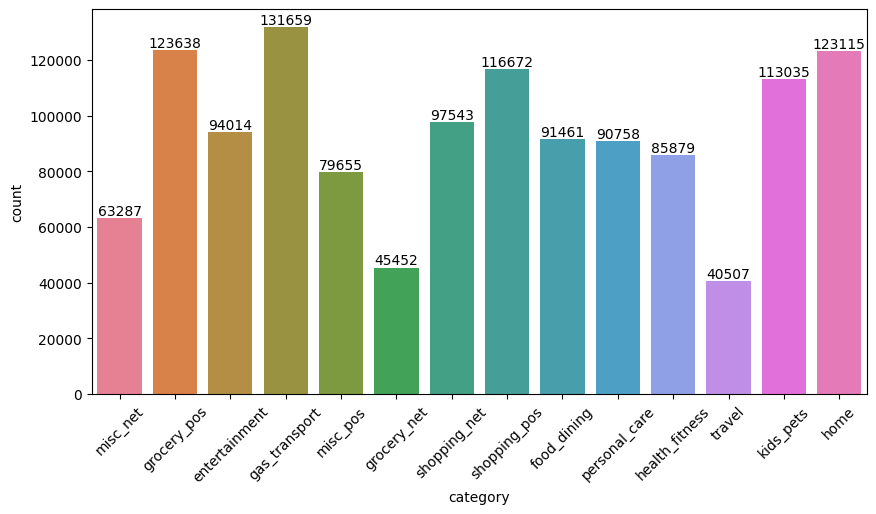

In [11]:
plt.figure(figsize=(10,5))
a = sns.countplot(x="category",data=train,hue="category")
plt.xticks(rotation=45)
data_label(a)
plt.show()

<Axes: xlabel='amt', ylabel='Count'>

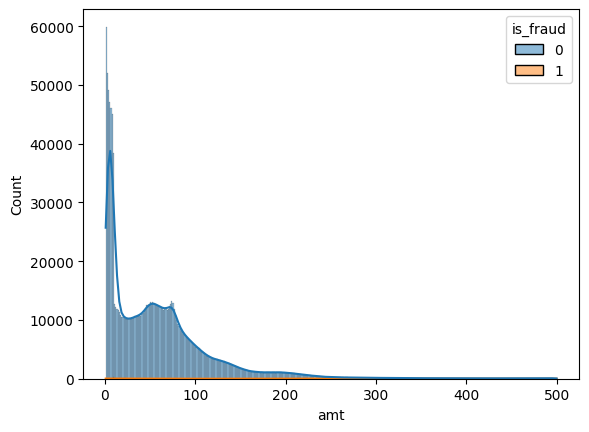

In [12]:
sns.histplot(x="amt",data=train[train["amt"]<500],kde=True,hue="is_fraud")

Most transactions had done between $1 to $100

<Axes: xlabel='is_fraud', ylabel='count'>

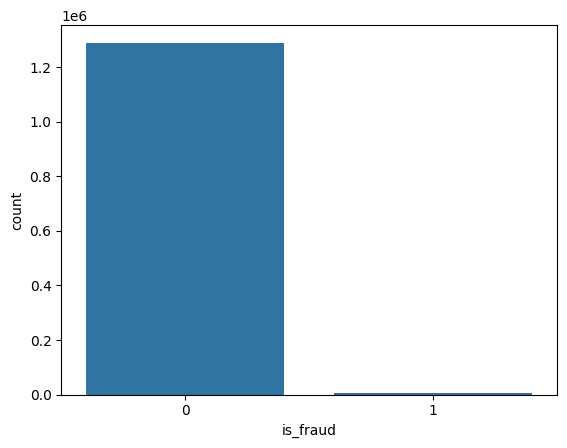

In [13]:
sns.countplot(x="is_fraud",data=train)

This dataset is highly imbalanced

In [14]:
#one hot encoding 
train = pd.get_dummies(train,drop_first=True,dtype=int)

In [15]:
#Divide into input and output
Xtrain = train.drop("is_fraud",axis=1)
ytrain = train.is_fraud

In [16]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
Xtrain_resampled,ytrain_resampled = smote.fit_resample(Xtrain,ytrain)

In [17]:
ytrain_resampled.value_counts()

is_fraud
0    1289169
1    1289169
Name: count, dtype: int64

In [18]:
ytrain.value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64